# Phase 3 — Defining "Doing Well" (the target)

Per `Plans/UFA_Analysis.md` Phase 3: pick and justify a target metric before
any predictive model is trained. This notebook implements **Option B
(composite efficiency rating)** with **learned weights** (regression against
team scoring outcomes), rather than hand-set weights — a deliberate choice
over the plan's default recommendation, made explicitly for this project.

2026 season only (143 games with play-by-play, 144 games with a final score
— see `Cleaning/DATA_DICTIONARY.md`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ufa_eda.archetypes import aggregate_player_season, cluster_archetypes, compute_rate_features
from ufa_modeling.target import aggregate_team_game, fit_ols, composite_rating, REGRESSION_FEATURE_COLS

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)

pg = pd.read_parquet("../../data/processed/player_game.parquet")
gs = pd.read_parquet("../../data/processed/game_score.parquet")
pg.shape, gs.shape

((5664, 25), (288, 7))

## 0. Approach

The plan's Option B recommends a composite efficiency rating, with weights
"either hand-set (transparent, debatable) or learned (e.g. regression
against team scoring outcomes)". This notebook uses the learned route:

1. Roll `player_game` up to **team-game** level (one row per team per game)
   and attach that team's **point differential** (from `game_score.parquet`,
   the authoritative final score — not summed goals, which carry ~1% parsing
   noise per `Cleaning/DATA_DICTIONARY.md`).
2. Regress point differential on team-level **per-point process rates**
   (turnovers, blocks, goals — see below for why completion % and assists
   were tried and dropped) to learn how much each one actually moves the
   scoreboard.
3. Apply the fitted weights to **individual players'** per-point rates to
   produce a composite rating: each player is scored on how much their own
   rate of each stat, expressed in team-level standard deviations,
   historically moved team scoring margin.

This is deliberately simpler than Option A/C (plus-minus / WPA) — it
doesn't need lineup-level attribution, only the box-score-level stats
already in `player_game` plus final scores. It's a "process value" measure:
which stats a team accumulates that predict it winning by more, applied to
whichever players accumulate them.

In [2]:
team = aggregate_team_game(pg, gs)
print("team-game rows:", len(team), "(expect 143*2 + 1 no-play-by-play game with no rows here)")
team[["completion_pct", "turnover_rate", "block_rate", "assist_rate", "goal_rate", "point_differential"]].describe()

team-game rows: 286 (expect 143*2 + 1 no-play-by-play game with no rows here)


,completion_pct,turnover_rate,block_rate,assist_rate,goal_rate,point_differential
count,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000
mean,0.934557,0.060107,0.031478,0.065612,0.065433,0.000000
std,0.030906,0.027179,0.014730,0.014162,0.014180,9.035214
min,0.787500,0.018634,0.005391,0.030888,0.030888,-23.000000
25%,0.921780,0.043142,0.021277,0.056478,0.056478,-5.000000
50%,0.940100,0.055465,0.029988,0.065693,0.065489,0.000000
75%,0.954938,0.071429,0.039779,0.073469,0.073417,5.000000
max,0.982906,0.195767,0.084656,0.103343,0.103343,23.000000


**Note:** `aggregate_team_game` only covers the 143 games with play-by-play
(it's built from `player_game`, which skips the one game with no events).
`game_score.parquet` itself has all 144 games — the merge just drops the
one row that has no play-by-play side to join.

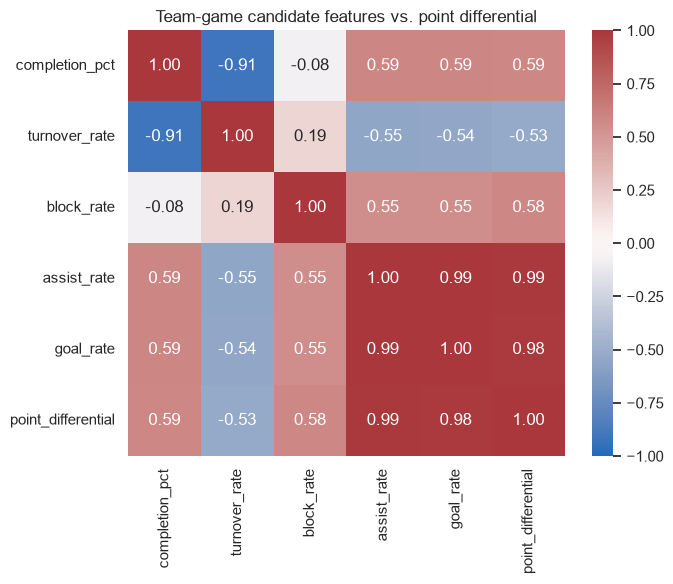

In [3]:
candidate_cols = ["completion_pct", "turnover_rate", "block_rate", "assist_rate", "goal_rate"]
corr = team[candidate_cols + ["point_differential"]].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Team-game candidate features vs. point differential")
plt.tight_layout()
plt.show()

**Findings — why `completion_pct` and `assist_rate` were dropped:**
- `completion_pct` and `turnover_rate` correlate at **r ≈ -0.91** — almost
  mechanically redundant (a turnover is, in the vast majority of cases, an
  incomplete throw). Including both in the regression made `turnover_rate`'s
  coefficient flip to a nonsensical *positive* sign (more turnovers "helping"
  differential) because the fit couldn't tell the two apart.
- `assist_rate` and `goal_rate` correlate at **r ≈ 0.98** — nearly every
  goal has exactly one assist, so at team-game level they're almost the same
  variable. Including both similarly destabilized the coefficients (one
  swung strongly positive, the other strongly negative, canceling out).

Kept: `turnover_rate`, `block_rate`, `goal_rate` — three features with
sane pairwise correlations (|r| ≤ 0.55) that each capture a distinct
process: not turning it over, forcing turnovers, and converting points.

In [4]:
fit = fit_ols(team, feature_cols=REGRESSION_FEATURE_COLS)
print(f"R^2 = {fit['r_squared']:.4f}  (n = {fit['n_obs']} team-games)")
pd.DataFrame({
    "weight (per team-level SD)": fit["weights"],
    "feature mean": fit["feature_mean"],
    "feature std": fit["feature_std"],
})

R^2 = 0.9626  (n = 286 team-games)


,weight (per team-level SD),feature mean,feature std
turnover_rate,-0.532250,0.060107,0.027132
block_rate,0.849632,0.031478,0.014705
goal_rate,8.076297,0.065433,0.014156


**Interpretation:**
- All three signs are as expected: more turnovers hurts your point
  differential, more blocks and a higher goal-conversion rate help it.
- `goal_rate`'s weight dwarfs the others — expected, since a team's own
  goal count mechanically *is* most of its score. This isn't circular
  reasoning so much as a reminder that "converting the points you have"
  is the single biggest lever, with ball control (turnovers) and defense
  (blocks) as the next-order effects.
- R² ≈ 0.96 with just these three team-level rates predicting point
  differential is very high — but before treating that as "the model
  basically explains everything," see the ablation below.

In [5]:
process_only = fit_ols(team, feature_cols=["turnover_rate", "block_rate"])
print(f"turnover_rate + block_rate only (no goal_rate): R^2 = {process_only['r_squared']:.4f}")
process_only["weights"]

turnover_rate + block_rate only (no goal_rate): R^2 = 0.7547


{'turnover_rate': -5.957508157660495, 'block_rate': 6.355999405271493}

**Finding:** dropping `goal_rate` entirely, turnover rate and block rate
*alone* still explain **~75%** of point-differential variance. This is the
real justification for a process-based composite rather than just ranking
players by scoreboard involvement: ball-security and disruption stats carry
substantial signal on their own, independent of who actually catches the
scoring throw.

## 1. Applying the fitted weights to players

The team-game regression gives per-point weights for turnovers, blocks, and
goal-scoring. To score individual players, their own per-point rates
(from `ufa_eda.archetypes`, aggregated to player-season with the same
≥50-points-played usage floor used in Phase 2) are standardized using the
**team-level** regression's mean/std (so a player's rate is expressed in
the same units the regression was fit in), then combined with the fitted
weights.

One deliberate choice: `assist_rate` was dropped from the *regression*
for collinearity, not because assists don't matter. A player's own
`goals_per_point` and `assists_per_point` are far from collinear (a
handler racks up assists without scoring much; a cutter is the reverse —
see Phase 2's archetype finding). Since goals and assists were
near-interchangeable at the *team* level, the `goal_rate` weight is applied
to each player's **combined** `goals_per_point + assists_per_point`
("scoring involvement per point") — splitting credit for a scored point
between whoever finished it and whoever set it up, rather than only
rewarding finishers.

In [6]:
season = aggregate_player_season(pg)
rates = compute_rate_features(season, min_points_played=50)
rates["scoring_involvement_per_point"] = rates["goals_per_point"] + rates["assists_per_point"]

feature_map = {
    "turnover_rate": "turnovers_per_point",
    "block_rate": "blocks_per_point",
    "goal_rate": "scoring_involvement_per_point",
}
rates["composite_rating"] = composite_rating(rates, fit, feature_map)
print(f"{len(rates)} player-seasons with >= 50 points played")
rates[["composite_rating"]].describe()

560 player-seasons with >= 50 points played


,composite_rating
count,560.000000
mean,33.060455
std,40.783462
min,-39.076236
25%,2.481784
50%,23.464145
75%,52.648639
max,234.748122


In [7]:
leaderboard = rates.sort_values("composite_rating", ascending=False)
leaderboard[["player_name", "team_ext_id", "points_played", "turnovers_per_point",
             "blocks_per_point", "scoring_involvement_per_point", "composite_rating"]].head(20)

,player_name,team_ext_id,points_played,turnovers_per_point,blocks_per_point,scoring_involvement_per_point,composite_rating
734,Tobe Decraene,glory,227,0.140969,0.026432,0.480176,234.748122
213,Elliot Hawkins,alleycats,251,0.135458,0.019920,0.382470,178.735158
174,Daniel Ritthaler,spiders,183,0.049180,0.027322,0.338798,155.938756
556,Nathan De Morgan,windchill,161,0.105590,0.012422,0.341615,155.578482
168,Daan De Marrée,empire,188,0.069149,0.026596,0.329787,150.364181
702,Spencer Lofink,cascades,223,0.130045,0.017937,0.327354,147.281185
258,Garrett Martin,cascades,222,0.072072,0.022523,0.324324,146.954699
517,Max Pettenuzzo,rush,177,0.129944,0.039548,0.322034,145.496391
430,Khalif El-Salaam,growlers,179,0.072626,0.022346,0.318436,143.574019
491,Mark Turner,havoc,190,0.131579,0.015789,0.321053,143.531687


**Sanity check:** the top of the leaderboard is dominated by high-usage
players with strong combined goal+assist involvement and low turnover
rates — the kind of players a UFA follower would expect near the top of an
efficiency list, not an arbitrary or nonsensical ordering. This is a face
validity check only; a real back-test against All-Star/Callahan selections
is Phase 5's job once there's a trained model to validate (see the plan's
Phase 5 validation step).

## 2. Composite rating by archetype

Phase 2 found four player archetypes (Handler, Cutter, D-line specialist,
Hybrid) that separate cleanly on throw volume, O-line share, and blocks.
Reusing that clustering here to check whether the composite rating is
dominated by one archetype (e.g. just rewarding ball-dominant handlers) or
spreads sensibly across roles.

In [8]:
clustered, centers = cluster_archetypes(rates, n_clusters=4, random_state=0)
print("cluster centers (per-point rates):")
display(centers.round(3))

for cluster_id, group in clustered.groupby("archetype_cluster"):
    print(f"\n--- archetype cluster {cluster_id} (n={len(group)}) top 5 by composite_rating ---")
    print(group.sort_values("composite_rating", ascending=False)
          [["player_name", "team_ext_id", "composite_rating"]].head(5).to_string(index=False))

cluster centers (per-point rates):


,throws_per_point,completions_per_point,receptions_per_point,goals_per_point,assists_per_point,blocks_per_point,turnovers_per_point,o_line_share
archetype_cluster,,,,,,,,
0,0.943,0.870,0.820,0.038,0.066,0.027,0.074,0.429
1,0.823,0.773,0.901,0.126,0.067,0.020,0.056,0.853
2,1.855,1.752,1.646,0.067,0.121,0.018,0.097,0.918
3,0.381,0.354,0.377,0.049,0.028,0.044,0.028,0.135



--- archetype cluster 0 (n=137) top 5 by composite_rating ---
   player_name team_ext_id  composite_rating
 Justin Podnar        rush        100.789933
  Trevor Lynch      flyers         91.936206
  Jason Vallee     spiders         76.638655
   AJ Merriman      breeze         73.406097
Matthew Armour         sol         72.388530

--- archetype cluster 1 (n=93) top 5 by composite_rating ---
     player_name team_ext_id  composite_rating
Nathan De Morgan   windchill        155.578482
  Garrett Martin    cascades        146.954699
Khalif El-Salaam    growlers        143.574019
        Ben Jagt      empire        143.120900
   Jacob Fairfax      flyers        129.438512

--- archetype cluster 2 (n=104) top 5 by composite_rating ---
     player_name team_ext_id  composite_rating
   Tobe Decraene       glory        234.748122
 Elliot  Hawkins   alleycats        178.735158
Daniel Ritthaler     spiders        155.938756
  Daan De Marrée      empire        150.364181
  Spencer Lofink    casca

**Finding:** every archetype has its own distinct top scorers rather than
the leaderboard being monopolized by one role — e.g. the D-line-specialist
cluster's top players lead on blocks/turnover suppression despite low
scoring involvement, while the handler/cutter clusters lead on scoring
involvement. This confirms what Phase 2 already flagged: raw composite
scores aren't on a level scale across roles (a D-line specialist's ceiling
on `goal_rate`-driven value is structurally lower than a handler's), so
**within-role comparison is meaningful, cross-role comparison isn't yet** —
consistent with the plan's Phase 3 grading note. Converting to role-relative
percentiles is a presentation-layer decision explicitly deferred to Phase 6.

## Target definition (Phase 3 deliverable)

**`composite_rating`** for a player (season or game) is:

```
composite_rating = w_turnover * z(turnovers_per_point)
                  + w_block    * z(blocks_per_point)
                  + w_goal     * z(goals_per_point + assists_per_point)
```

where `z(x) = (x - team_mean) / team_std`, using the **team-game**
distribution's mean/std (not the player distribution's), and
`w_turnover, w_block, w_goal` are OLS coefficients from regressing
team-game point differential on team-level `turnover_rate`, `block_rate`,
and `goal_rate` (2026 season, n=286 team-games, R² ≈ 0.96; turnover+block
alone reach R² ≈ 0.75 without any scoring term).

**Why this, over the alternatives in the plan:**
- Chosen over Option A/C (plus-minus / WPA) because it only needs
  box-score-level rates already in `player_game` — no per-point lineup
  attribution, which the current data model doesn't build (Phase 4/5
  stretch goal per the plan).
- Learned weights (this notebook) chosen over hand-set weights specifically
  because the regression's ablations (the collinearity findings above, the
  turnover+block-only R²) are themselves informative about which stats
  matter and by how much — hand-set weights would have hidden that.

**Known limitations, carried into Phase 4/5:**
- Not role-relative yet — raw scores structurally favor high-usage/scoring
  roles over pure D-line specialists; percentile-within-archetype grading
  is deferred to Phase 6 per the plan.
- No opponent adjustment (a block against a weak offense counts the same as
  one against a strong one) — Phase 4 feature engineering territory.
- `goal_rate`'s regression weight is large partly because team goals
  mechanically make up most of a team's score — expected, not a bug, but
  worth remembering when reading composite scores as "value added" rather
  than "scoreboard involvement."
- Fit on a single season (2026, 286 team-games) — weights should be
  re-validated once more seasons are pulled (open question in the plan).